#  Neural Networks with PyTorch

## 1. Setup

In [1]:
# Basic imports
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

---

## 2. Load MNIST CSV

In [2]:
# Load training and test CSVs
train_df = pd.read_csv("mnist_train.csv")
test_df = pd.read_csv("mnist_test.csv")

# Separate labels and pixels
X_train = train_df.drop("label", axis=1).values
y_train = train_df["label"].values

X_test = test_df.drop("label", axis=1).values
y_test = test_df["label"].values

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (6000, 784) (6000,)
Test shape: (1000, 784) (1000,)


---

## 3. Normalize the Data

In [3]:
# Normalize pixel values to [0,1]
X_train = X_train / 255.0
X_test = X_test / 255.0

---

## 4. Create PyTorch Dataset

In [4]:
class MNISTDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = MNISTDataset(X_train, y_train)
test_dataset = MNISTDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

---

## 5. Define a Simple Neural Network

In [5]:
class SimpleNN(nn.Module):
    def __init__(self, input_size=784, hidden_size=128, num_classes=10):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, num_classes)
        
    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out

model = SimpleNN()
print(model)

SimpleNN(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


---

## 6. Define Loss and Optimizer

In [6]:
criterion = nn.CrossEntropyLoss()  # combines Softmax + NLLLoss
optimizer = optim.Adam(model.parameters(), lr=0.001)

---

## 7. Training Loop

In [7]:
num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * X_batch.size(0)
    
    epoch_loss = running_loss / len(train_loader.dataset)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}")

Epoch 1/5, Loss: 0.9863
Epoch 2/5, Loss: 0.3856
Epoch 3/5, Loss: 0.2959
Epoch 4/5, Loss: 0.2446
Epoch 5/5, Loss: 0.2090


---

## 8. Evaluate Accuracy

In [8]:
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        _, predicted = torch.max(outputs, 1)
        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()

accuracy = correct / total
print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.8890


---

## 9. Try Predicting a Single Sample

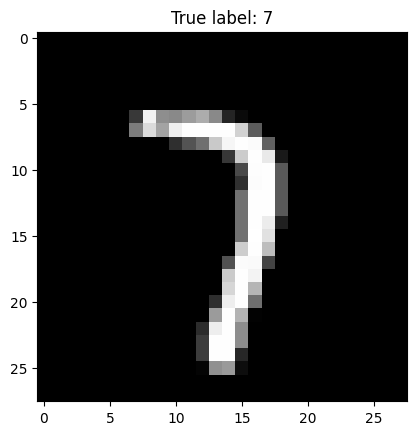

Predicted label: 7


In [9]:
import matplotlib.pyplot as plt

sample_idx = 0
sample_image = X_test[sample_idx].reshape(28,28)
plt.imshow(sample_image, cmap='gray')
plt.title(f"True label: {y_test[sample_idx]}")
plt.show()

model.eval()
with torch.no_grad():
    sample_tensor = torch.tensor(X_test[sample_idx], dtype=torch.float32)
    sample_tensor = sample_tensor.unsqueeze(0)
    output = model(sample_tensor)
    predicted_label = torch.argmax(output, 1).item()
print("Predicted label:", predicted_label)